In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
from scipy.ndimage import gaussian_filter1d

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)

def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [3]:
### Function to get aligned dataframe for closed loop sessions.
def live_aligned_df(mouse_id,date,sess = "1",pre = 10,post = 10):

    path_start = fr"{base_dir}/{mouse_id}/{date}/"
    df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_areas.csv", names=["Area","Time"])
    dilation_df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_dilations.csv", names=["Times"])
    lasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_laser.csv", names=["Times"])["Times"].tolist()
    nonlasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_nonlasers.csv", names=["Times"])["Times"].tolist()

    dil_times = dilation_df["Times"].tolist()
    Area = df["Area"].tolist()
    Area =[x if x != 0 else np.nan for x in Area]
    Time = [i - df["Time"].tolist()[0] for i in df["Time"].tolist()]
    Dil_times = [i - df["Time"].tolist()[0] for i in dil_times]
    Lasers = [i - df["Time"].tolist()[0] for i in lasers]
    Nonlasers = [i - df["Time"].tolist()[0] for i in nonlasers]
    nan_removed_area = np.delete(Area, np.argwhere(np.isnan(Area)))
    nan_removed_times = np.delete(Time, np.argwhere(np.isnan(Area)))
    Time = np.arange(0,Time[-1],0.05)
    area = np.interp(Time, nan_removed_times, nan_removed_area)
    Area = zscore(area)
    Lasers = np.array(Lasers)
    Nonlasers = np.array(Nonlasers)
    Time = np.array(Time)
    Area = np.array(Area)
    laser_matrix,dil_times = trial_align(Lasers,Time,Area,fps = 20,pre = pre, post = post)
    df_list = []
    for j,trial in enumerate(laser_matrix):
        ##check if slope during trial is positive
        p = gaussian_filter1d(trial,20)
        p_deriv = np.gradient(p,dil_times)
        slope = np.mean(p_deriv[160:200])
        if slope >0:
            for i,time in enumerate(dil_times):
                new_dict = {"Time from Stim (s)" : np.round(time,2), "trial" : j, "Pupil Area" : trial[i],"Type":"Laser Trial","ID":mouse_id,"Date":date}
                df_list.append(new_dict)

    nonlaser_matrix,dil_times = trial_align(Nonlasers,Time,Area,fps = 20,pre = pre, post = post)
    for j,trial in enumerate(nonlaser_matrix):
        ##check if slope during trial is positive
        p = gaussian_filter1d(trial,20)
        p_deriv = np.gradient(p,dil_times)
        slope = np.mean(p_deriv[160:200])
        if slope >0:
            for i,time in enumerate(dil_times):
                new_dict = {"Time from Stim (s)" : np.round(time,2), "trial" : j, "Pupil Area" : trial[i],"Type":"Non-Laser Trial","ID":mouse_id,"Date":date}
                df_list.append(new_dict)
    aligned_df = pd.DataFrame.from_dict(df_list)
    return aligned_df


In [4]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [5]:
### Get ACC data for FigS4A, S4B

id_date = { 
"004072" : ["20230727","20230726"],
"004075" : ["20230727","20230726"],
"004109" : ["20230907","20230908"],
"004112" : ["20230908"],
"004110" : ["20230911"],
"004111" : ["20230911"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
ACC_df = df.reset_index()

004072 20230727
004072 20230726
004075 20230727
004075 20230726
004109 20230907
004109 20230908
004112 20230908
004110 20230911
004111 20230911


In [6]:
### Get AUC and Peak metrics for FigS4A, S4B

bar_df_list = []
for ID in ACC_df.ID.unique():
    mouse_df = ACC_df.query(f"ID =='{ID}'")
    for date in mouse_df.Date.unique():
        date_df = mouse_df.query(f"Date =='{date}'")
        for type in date_df.Type.unique():
            type_df = date_df.query(f"Type =='{type}'")
            for trial in type_df.trial.unique():            
                trial_df = type_df.query(f"trial =={trial}")
                rslt_df = trial_df.loc[trial_df['Time from Stim (s)'] > 0]
                rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 5]
                area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
                time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
                peak = max(area)
                peak_ix = np.argmax(area)
                p_50 = peak*0.5
                p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
                new_dict = {"ID" : ID,"type": type,"Peak":peak,"AUC":np.trapz(area,time),"trial":trial,"date":date}
                bar_df_list.append(new_dict)

ACC_metrics_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/900143276.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/900143276.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/900143276.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depreca

In [7]:
### Get t50 metric for FigS4A, S4B

bar_df_list = []
for ID in ACC_df.ID.unique():
    mouse_df = ACC_df.query(f"ID =='{ID}'")
    for date in mouse_df.Date.unique():
        date_df = mouse_df.query(f"Date =='{date}'")
        for type in date_df.Type.unique():
            type_df = date_df.query(f"Type =='{type}'")
            for trial in type_df.trial.unique():            
                trial_df = type_df.query(f"trial =={trial}")
                rslt_df = trial_df.loc[trial_df['Time from Stim (s)'] > 0]
                rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
                area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
                time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
                peak = max(area)
                peak_ix = np.argmax(area)
                p_50 = peak*0.5
                p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
                time_to_50 = (p_50_ix-peak_ix)/20
                new_dict = {"ID" : ID,"type": type,"T50":time_to_50,"trial":trial,"date":date}
                bar_df_list.append(new_dict)

ACC_t50_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3318283500.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3318283500.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3318283500.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depr

In [8]:
### Clip data for histogram visualization

ACC_metrics_df["AUC_clipped"] = ACC_metrics_df["AUC"].clip(upper=14.9999)
ACC_metrics_df["Peak_clipped"] = ACC_metrics_df["Peak"].clip(upper=4.9999)
ACC_t50_df["T50_clipped"] = ACC_t50_df["T50"].clip(upper=4.9999)

In [9]:
### Sample trials for FigS4B

rng = np.random.default_rng(42)
# Sample 10 Laser and 10 Non-Laser trials per ID
ACC_metrics_sampled_df = (
    ACC_metrics_df
    .groupby(['ID', 'type'], group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=rng) if len(x) >= 10 else x)
    .reset_index(drop=True)
)

rng = np.random.default_rng(42)
ACC_t50_sampled_df = (
    ACC_t50_df
    .groupby(['ID', 'type'], group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=rng) if len(x) >= 10 else x)
    .reset_index(drop=True)
)

[Text(-10, 0, '−10'),
 Text(-5, 0, '−5'),
 Text(0, 0, '0'),
 Text(5, 0, '5'),
 Text(10, 0, '10'),
 Text(15, 0, '15+')]

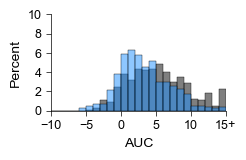

In [10]:
### Plot FigS4A (Left)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(-10, 31, 1)
ax = sns.histplot(data = ACC_metrics_df, x = "AUC_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(-10,15),(0,10),5,2)
ax.set(xlabel ="AUC")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '15+'
ax.set_xticklabels(labels)

[Text(-1, 0, '−1'),
 Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5+')]

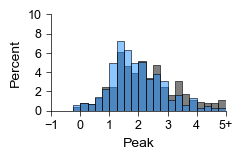

In [11]:
### Plot FigS4A (Middle)
plt.figure(figsize = (2.25,1.25))
bins = np.arange(-1, 6, 0.25)
ax = sns.histplot(data = ACC_metrics_df, x = "Peak_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(-1,5),(0,10),1,2)
ax.set(xlabel ="Peak")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '5+'
ax.set_xticklabels(labels)

[Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5+')]

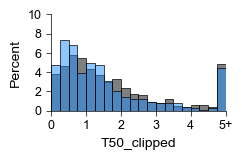

In [12]:
### Plot FigS4A (Right)
plt.figure(figsize = (2.25,1.25))
bins = np.arange(0, 6, 0.25)
ax = sns.histplot(data = ACC_t50_df, x = "T50_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(0,5),(0,10),1,2)
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '5+'
ax.set_xticklabels(labels)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/1464248072.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


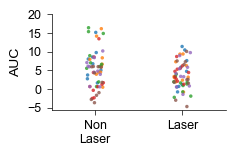

In [13]:
### Plot FigS4B (Left)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = ACC_metrics_sampled_df, x = "type", y = "AUC",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-5,25,5))

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2099043696.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


[(-1.0, 6.0)]

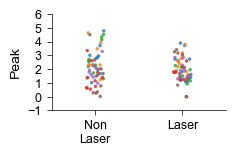

In [14]:
### Plot FigS4B (Middle)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = ACC_metrics_sampled_df, x = "type", y = "Peak",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-2,7,1))
g.set(ylim=(-1, 6))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/1968213209.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


[(-2.0, 10.0)]

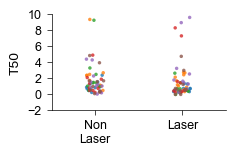

In [15]:
### Plot FigS4B (Right)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = ACC_t50_sampled_df, x = "type", y = "T50",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-2,12,2))
g.set(ylim=(-2, 10))

In [16]:
### Get mCherry data for FigS4C, S4D

id_date = { 
"004259" : ["20240514"],
"004260" : ["20240514","20240517"],
"004261" : ["20240514"],
"004262" : ["20240514","20240522"],
"004263" : ["20240522"],
"004264" : ["20240514"],
 }

df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
mCherry_df = df.reset_index()

004259 20240514
004260 20240514
004260 20240517
004261 20240514
004262 20240514
004262 20240522
004263 20240522
004264 20240514


In [17]:
### Get AUC and Peak metrics for FigS4C, S4D

bar_df_list = []
for ID in mCherry_df.ID.unique():
    mouse_df = mCherry_df.query(f"ID =='{ID}'")
    for date in mouse_df.Date.unique():
        date_df = mouse_df.query(f"Date =='{date}'")
        for type in date_df.Type.unique():
            type_df = date_df.query(f"Type =='{type}'")
            for trial in type_df.trial.unique():            
                trial_df = type_df.query(f"trial =={trial}")
                rslt_df = trial_df.loc[trial_df['Time from Stim (s)'] > 0]
                rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 5]
                area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
                time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
                peak = max(area)
                peak_ix = np.argmax(area)
                p_50 = peak*0.5
                p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
                new_dict = {"ID" : ID,"type": type,"Peak":peak,"AUC":np.trapz(area,time),"trial":trial,"date":date}
                bar_df_list.append(new_dict)

mCherry_metrics_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2600144564.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2600144564.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2600144564.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depr

In [18]:
### Get t50 metric for FigS4C, S4D

bar_df_list = []
for ID in mCherry_df.ID.unique():
    mouse_df = mCherry_df.query(f"ID =='{ID}'")
    for date in mouse_df.Date.unique():
        date_df = mouse_df.query(f"Date =='{date}'")
        for type in date_df.Type.unique():
            type_df = date_df.query(f"Type =='{type}'")
            for trial in type_df.trial.unique():            
                trial_df = type_df.query(f"trial =={trial}")
                rslt_df = trial_df.loc[trial_df['Time from Stim (s)'] > 0]
                rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
                area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
                time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
                peak = max(area)
                peak_ix = np.argmax(area)
                p_50 = peak*0.5
                p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
                time_to_50 = (p_50_ix-peak_ix)/20
                new_dict = {"ID" : ID,"type": type,"T50":time_to_50,"trial":trial,"date":date}
                bar_df_list.append(new_dict)

mCherry_t50_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2000135099.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2000135099.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2000135099.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depr

In [19]:
### Clip data for histogram visualization

mCherry_metrics_df["AUC_clipped"] = mCherry_metrics_df["AUC"].clip(upper=14.9999)
mCherry_metrics_df["Peak_clipped"] = mCherry_metrics_df["Peak"].clip(upper=4.9999)
mCherry_t50_df["T50_clipped"] = mCherry_t50_df["T50"].clip(upper=4.9999)

In [20]:
### Sample trials for FigS4C

rng = np.random.default_rng(4304)
# Sample 10 Laser and 10 Non-Laser trials per ID
mCherry_metrics_sampled_df = (
    mCherry_metrics_df
    .groupby(['ID', 'type'], group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=rng) if len(x) >= 10 else x)
    .reset_index(drop=True)
)

rng = np.random.default_rng(4304)

mCherry_t50_sampled_df = (
    mCherry_t50_df
    .groupby(['ID', 'type'], group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=rng) if len(x) >= 10 else x)
    .reset_index(drop=True)
)

[Text(-10, 0, '−10'),
 Text(-5, 0, '−5'),
 Text(0, 0, '0'),
 Text(5, 0, '5'),
 Text(10, 0, '10'),
 Text(15, 0, '15+')]

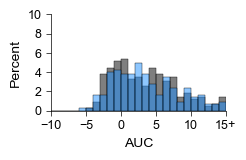

In [21]:
### Plot FigS4C (Left)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(-10, 31, 1)
ax = sns.histplot(data = mCherry_metrics_df, x = "AUC_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(-10,15),(0,10),5,2)
ax.set(xlabel ="AUC")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '15+'
ax.set_xticklabels(labels)

[Text(-1, 0, '−1'),
 Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5+')]

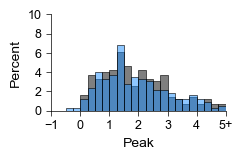

In [22]:
### Plot FigS4C (Middle)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(-1, 6, 0.25)
ax = sns.histplot(data = mCherry_metrics_df, x = "Peak_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(-1,5),(0,10),1,2)
ax.set(xlabel ="Peak")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '5+'
ax.set_xticklabels(labels)

[Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5+')]

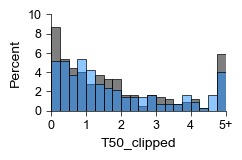

In [23]:
### Plot FigS4C (Right)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(0, 6, 0.25)
ax = sns.histplot(data = mCherry_t50_df, x = "T50_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(0,5),(0,10),1,2)
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '5+'
ax.set_xticklabels(labels)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/513553338.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


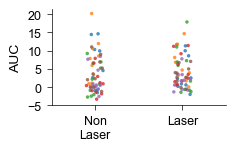

In [24]:
### Plot FigS4D (Left)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = mCherry_metrics_sampled_df, x = "type", y = "AUC",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-5,25,5))

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/667023802.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


[(-1.0, 6.0)]

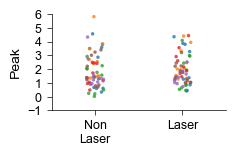

In [25]:
### Plot FigS4D (Middle)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = mCherry_metrics_sampled_df, x = "type", y = "Peak",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-2,7,1))
g.set(ylim=(-1, 6))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2756009942.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


[(-2.0, 10.0)]

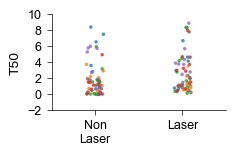

In [26]:
### Plot FigS4D (Right)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = mCherry_t50_sampled_df, x = "type", y = "T50",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-2,12,2))
g.set(ylim=(-2, 10))

In [27]:
### Get V1 data for FigS4E, S4F

id_date = { 
"004253" : ["20240520"],
"004254" : ["20240521"],
"004255" : ["20240521"],
"004256" : ["20240521"],
"004257" : ["20240521"],
"004258" : ["20240521"],
 }

df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
V1_df = df.reset_index()

004253 20240520
004254 20240521
004255 20240521
004256 20240521
004257 20240521
004258 20240521


In [28]:
### Get AUC and Peak metrics for FigS4E, S4F

bar_df_list = []
for ID in V1_df.ID.unique():
    mouse_df = V1_df.query(f"ID =='{ID}'")
    for date in mouse_df.Date.unique():
        date_df = mouse_df.query(f"Date =='{date}'")
        for type in date_df.Type.unique():
            type_df = date_df.query(f"Type =='{type}'")
            for trial in type_df.trial.unique():            
                trial_df = type_df.query(f"trial =={trial}")
                rslt_df = trial_df.loc[trial_df['Time from Stim (s)'] > 0]
                rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 5]
                area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
                time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
                peak = max(area)
                peak_ix = np.argmax(area)
                p_50 = peak*0.5
                p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
                new_dict = {"ID" : ID,"type": type,"Peak":peak,"AUC":np.trapz(area,time),"trial":trial,"date":date}
                bar_df_list.append(new_dict)

V1_metrics_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/4030319852.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/4030319852.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/4030319852.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depr

In [29]:
### Get t50 metric for FigS4C, S4D

bar_df_list = []
for ID in V1_df.ID.unique():
    mouse_df = V1_df.query(f"ID =='{ID}'")
    for date in mouse_df.Date.unique():
        date_df = mouse_df.query(f"Date =='{date}'")
        for type in date_df.Type.unique():
            type_df = date_df.query(f"Type =='{type}'")
            for trial in type_df.trial.unique():            
                trial_df = type_df.query(f"trial =={trial}")
                rslt_df = trial_df.loc[trial_df['Time from Stim (s)'] > 0]
                rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
                area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
                time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
                peak = max(area)
                peak_ix = np.argmax(area)
                p_50 = peak*0.5
                p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
                time_to_50 = (p_50_ix-peak_ix)/20
                new_dict = {"ID" : ID,"type": type,"T50":time_to_50,"trial":trial,"date":date}
                bar_df_list.append(new_dict)

V1_t50_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3126086384.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3126086384.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3126086384.py:14: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depr

In [30]:
### Clip data for histogram visualization

V1_metrics_df["AUC_clipped"] = V1_metrics_df["AUC"].clip(upper=14.9999)
V1_metrics_df["Peak_clipped"] = V1_metrics_df["Peak"].clip(upper=4.9999)
V1_t50_df["T50_clipped"] = V1_t50_df["T50"].clip(upper=4.9999)

In [31]:
### Sample trials for FigS4C

rng = np.random.default_rng(402)
# Sample 10 Laser and 10 Non-Laser trials per ID
V1_metrics_sampled_df = (
    V1_metrics_df
    .groupby(['ID', 'type'], group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=rng) if len(x) >= 10 else x)
    .reset_index(drop=True)
)

rng = np.random.default_rng(402)

V1_t50_sampled_df = (
    V1_t50_df
    .groupby(['ID', 'type'], group_keys=False)
    .apply(lambda x: x.sample(n=10, random_state=rng) if len(x) >= 10 else x)
    .reset_index(drop=True)
)

[Text(-10, 0, '−10'),
 Text(-5, 0, '−5'),
 Text(0, 0, '0'),
 Text(5, 0, '5'),
 Text(10, 0, '10'),
 Text(15, 0, '15+')]

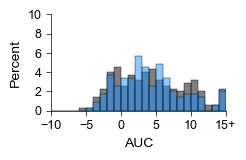

In [32]:
### Plot FigS4C (Left)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(-10, 31, 1)
ax = sns.histplot(data = V1_metrics_df, x = "AUC_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(-10,15),(0,10),5,2)
ax.set(xlabel ="AUC")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '15+'
ax.set_xticklabels(labels)

[Text(-1, 0, '−1'),
 Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5+')]

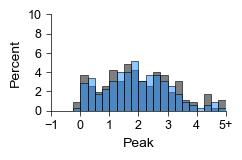

In [33]:
### Plot FigS4C (Middle)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(-1, 6, 0.25)
ax = sns.histplot(data = V1_metrics_df, x = "Peak_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(-1,5),(0,10),1,2)
ax.set(xlabel ="Peak")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '5+'
ax.set_xticklabels(labels)

[Text(0, 0, '0'),
 Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '4'),
 Text(5, 0, '5+')]

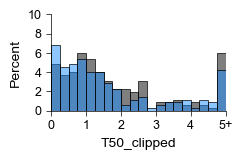

In [34]:
### Plot FigS4C (Right)

plt.figure(figsize = (2.25,1.25))
bins = np.arange(0, 6, 0.25)
ax = sns.histplot(data = V1_t50_df, x = "T50_clipped",hue = "type",palette = ["dodgerblue","black"],legend = None,bins = bins,stat = "percent")
format_ax(ax,(0,5),(0,10),1,2)
labels = [item.get_text() for item in ax.get_xticklabels()]
labels[-1] = '5+'
ax.set_xticklabels(labels)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/1205880105.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


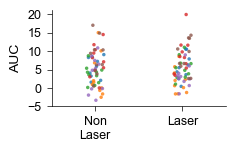

In [35]:
### Plot FigS4D (Left)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = V1_metrics_sampled_df, x = "type", y = "AUC",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-5,25,5))

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/2540841599.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


[(-1.0, 6.0)]

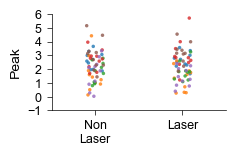

In [36]:
### Plot FigS4D (Middle)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = V1_metrics_sampled_df, x = "type", y = "Peak",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-2,7,1))
g.set(ylim=(-1, 6))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17786/3024161905.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(labels)


[(-2.0, 10.0)]

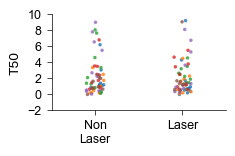

In [37]:
### Plot FigS4D (Right)

plt.figure(figsize = (2.25,1.25))
g = sns.stripplot(data = V1_t50_sampled_df, x = "type", y = "T50",hue = "ID",legend = None, order = ["Non-Laser Trial", "Laser Trial"],alpha = 0.8,s = 2.5)
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)
g.set_yticks(np.arange(-2,12,2))
g.set(ylim=(-2, 10))